# i.) Import Necessary Packages

In [1]:
!pip install lmfit
!pip install git+https://github.com/Schaeffer-Lab/Schaeffer_PlasmaPy
!pip install numba
!pip install numba_scipy
%matplotlib inline
import numpy as np
from plasmapy.diagnostics import thomson2 as thomson
import matplotlib.pyplot as plt
import astropy.units as u
import torch
from torch import Tensor
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from plasmapy.formulary import Maxwellian_1D
from plasmapy.diagnostics import thomsonVDF
from plasmapy.diagnostics import cpu_autodiff_thomson
import astropy.constants as const
torch.set_default_dtype(torch.float64)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Cloning https://github.com/Schaeffer-Lab/Schaeffer_PlasmaPy to /private/var/folders/x1/n8g05lb95ds78kqv9nzxm5cm0000gn/T/pip-req-build-n0w7zrdp
  Running command git clone --filter=blob:none --quiet https://github.com/Schaeffer-Lab/Schaeffer_PlasmaPy /private/var/folders/x1/n8g05lb95ds78kqv9nzxm5cm0000gn/T/pip-req-build-n0w7zrdp
  Resolved https://github.com/Schaeffer-Lab/Schaeffer_PlasmaPy to commit 74f1804783e664cb1d5fbb9fd6620692413ee95c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for plasmapy: filename=plasmapy-0.1.dev4706+g74f180478-py3-none-any.whl size=8714064 sha256=96f41b13f8688fb7a2f7a4994adb15122cc8506104ff3263cc5fabae0da509a9
  Stored in directory: /private/var/folders/x1/n8g05lb95ds78kqv9nzxm5cm0000gn/T/pip-ephem-wheel-cache-v0s7ejle/wheels/7c/3a/ce/64745a8f

## ii.) Define True Parameter Values

In [2]:
# All surface level user inputs must be declared here

# Declare true plasma params (TPP)
# [n]: m^-3
# [T]: eV
# [vd]: m/s
# p: Unitless

n_true = 4e24

e_T_true = 300.
e_vd_true = 1e5
e_p_true = 4.

i0_T_true = 200.
i0_vd_true = 1e5
i0_p_true = 4.

# Construct TPP as a dictionary of form: [n, e_T, e_p, e_vd, i0_vd, i0_p, i0_T]
TPP = {
    "n_true"    : n_true,
    "e_T_true"  : e_T_true,
    "e_p_true"  : e_p_true,
    "e_vd_true" : e_vd_true,
    "i0_vd_true": i0_vd_true,
    "i0_p_true" : i0_p_true,
    "i0_T_true" : i0_T_true
}

# Keep track of number of EPW and IAW params
NUM_ELECTRON_PARAMS = 4
NUM_ION_PARAMS = 3
NUM_PARAMS = NUM_ELECTRON_PARAMS + NUM_ION_PARAMS

# Choose number of parameters to vary (Done in order: [n, e_T, e_p, e_vd, i0_vd, i0_p, i0_T])
NUM_FREE_PARAMS = NUM_PARAMS



# Declare cutoff criteria for spectra fitting here
# Defined as difference between consecutive iterations
EPW_CUTOFF_CRITERIA = 1e-8
IAW_CUTOFF_CRITERIA = EPW_CUTOFF_CRITERIA * 10

# Set a flag for minimum number of iterations
MIN_NUM_ITERS = 500






# Generate param keys automatically from TPP
param_keys = []
for key in TPP.keys():
    param_keys.append(key[:-len("_true")])

electron_param_keys = []
for key in param_keys[:NUM_ELECTRON_PARAMS]:
    if key == "n": electron_param_keys.append("ln_"+key)
    elif key[0] == "e":
        if "T" in key: electron_param_keys.append("ln_"+key)
        else: electron_param_keys.append(key)
    else: raise ValueError("Invalid param key entered, check TPP dictionary!")

ion_param_keys = []
for key in param_keys[NUM_ELECTRON_PARAMS:]:
    if key[0] != "i": raise ValueError("Invalid param key entered, check TPP dictionary!")
    elif "T" in key: ion_param_keys.append("ln_"+key)
    else:  ion_param_keys.append(key)

# iii.) Generate True/Target Spectra

In [3]:
# Generate Super-Gaussian VDFs
def supergaussian_e(v, T, vd, p):
    T_K = T * 11605
    vth = np.sqrt(2 * 8.2544e3 * T_K * 1836)  # 1836 = Ratio of electron to proton mass
    vdf_unnormalized = np.exp(-np.abs((v - vd)) ** p / np.abs(vth) ** p)
    return vdf_unnormalized / np.trapz(vdf_unnormalized, v)

def supergaussian_H(v, T, vd, p):
    T_K = T * 11605
    vth = np.sqrt(2 * 8.2544e3 * T_K)
    vdf_unnormalized = np.exp(-np.abs((v - vd)  / (vth)) ** p)
    return vdf_unnormalized / np.trapz(vdf_unnormalized, v)

notch = np.array([520, 540])

In [4]:

probe_wavelength = 532 * u.nm
epw_wavelengths = np.linspace(probe_wavelength.value - 100, probe_wavelength.value + 100, num=200) * u.nm
iaw_wavelengths = np.linspace(probe_wavelength.value - 3, probe_wavelength.value + 3, num=200) * u.nm

ve = np.linspace(-2e7, 2e7, 500)
vH = np.linspace(-4e5, 6e5, 500)

fe_in = supergaussian_e(ve, e_T_true, e_vd_true, e_p_true)
fH_in = supergaussian_H(vH, i0_T_true, i0_vd_true, i0_p_true)
n = n_true * 1e-6   # Convert density from m^-3 to cm^-3

/var/folders/x1/n8g05lb95ds78kqv9nzxm5cm0000gn/T/ipykernel_21075/1537608429.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return vdf_unnormalized / np.trapz(vdf_unnormalized, v)
/var/folders/x1/n8g05lb95ds78kqv9nzxm5cm0000gn/T/ipykernel_21075/1537608429.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return vdf_unnormalized / np.trapz(vdf_unnormalized, v)


In [5]:
# Generate true spectra
alpha, epw_target = thomsonVDF.spectral_density_arbdist(
    wavelengths = epw_wavelengths,
    notches = [notch] * u.nm,
    probe_wavelength = probe_wavelength,
    e_velocity_axes = [ve] * u.m / u.s,
    i_velocity_axes = [vH] * u.m / u.s,
    efn = [fe_in] * u.s / u.m,
    ifn = [fH_in] * u.s / u.m,
    n = n * u.cm ** -3,
    scattered_power = True,
    ion_species = ['p']
)

alpha, iaw_target = thomsonVDF.spectral_density_arbdist(
    wavelengths = iaw_wavelengths,
    probe_wavelength = probe_wavelength,
    e_velocity_axes = [ve] * u.m / u.s,
    i_velocity_axes = [vH] * u.m / u.s,
    efn = [fe_in] * u.s / u.m,
    ifn = [fH_in] * u.s / u.m,
    n = n * u.cm ** -3,
    scattered_power = True,
    ion_species = ['p']
)


epw_target = torch.from_numpy(epw_target)
iaw_target = torch.from_numpy(iaw_target)

epw_sum = torch.sum(torch.square(epw_target))
iaw_sum = torch.sum(torch.square(iaw_target))

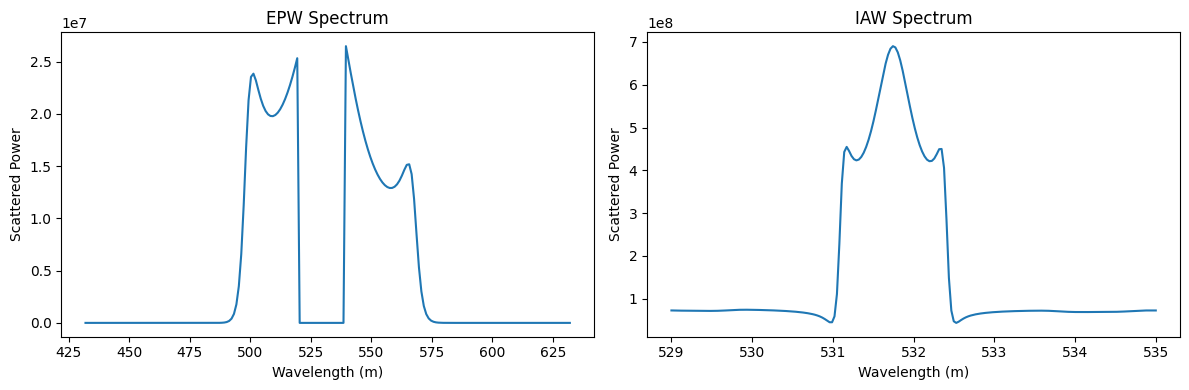

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)


axes[0].plot(epw_wavelengths, epw_target.numpy())
axes[0].set_xlabel("Wavelength (m)")
axes[0].set_ylabel("Scattered Power")
axes[0].set_title("EPW Spectrum")


axes[1].plot(iaw_wavelengths, iaw_target.numpy())
axes[1].set_xlabel("Wavelength (m)")
axes[1].set_ylabel("Scattered Power")
axes[1].set_title("IAW Spectrum")

plt.tight_layout()
plt.show()


# iiii.) Fit EPW and IAW



In [7]:
# Define Super-Gaussian functions to be compatible with PyTorch
def supergaussian_e_TORCH(v: Tensor, T: Tensor, vd: Tensor, p: Tensor):
    T_K = T * 11605
    vth = torch.sqrt(2 * 8.2544e3 * T_K * 1836)  # 1836 = Ratio of electron to proton mass
    exp_term1 = torch.abs((v - vd))
    exp_term2 = torch.abs(vth)
    vdf_unnormalized = torch.exp(-1. * torch.pow(exp_term1, p) / torch.pow(exp_term2, p))
    return vdf_unnormalized / torch.trapz(vdf_unnormalized, v)

def supergaussian_H_TORCH(v: Tensor, T: Tensor, vd: Tensor, p: Tensor):
    T_K = T * 11605
    vth = torch.sqrt(2 * 8.2544e3 * T_K)
    exp_term = torch.abs((v - vd) / (vth))
    vdf_unnormalized = torch.exp(-1. * torch.pow(exp_term, p))
    return vdf_unnormalized / torch.trapz(vdf_unnormalized, v)

In [8]:
# Provide manual initial guesses for parameters
fit_param_keys = electron_param_keys + ion_param_keys  # ["ln_n","ln_e_T","e_p","e_vd","i0_vd","i0_p","ln_i0_T"]


parameter_guesses = {
    "ln_n"     : 4e24,  
    "ln_e_T"   : 300., 
    "e_p"      : 4.,
    "e_vd"     : 1e5,    
    "i0_vd"    : 1e5,
    "i0_p"     : 4.,
    "ln_i0_T"  : 200.,  
}


missing = [k for k in fit_param_keys if k not in parameter_guesses]
extra   = [k for k in parameter_guesses if k not in fit_param_keys]
if missing:
    raise ValueError(f"Missing parameter guesses for: {missing}")
if extra:
    raise ValueError(f"Parameter guesses include unknown keys: {extra}")

# 4) Build init_guesses (manual only)
init_guesses = {k: parameter_guesses[k] for k in fit_param_keys}




init_guesses_keys = list(init_guesses.keys())

# Separate electron and ion params into their own dictionaries
electron_params = {}
for i in range(NUM_ELECTRON_PARAMS):
    if "ln" in electron_param_keys[i]: electron_params[electron_param_keys[i]] = torch.log(torch.tensor([init_guesses[init_guesses_keys[i]]]))
    else: electron_params[electron_param_keys[i]] = torch.tensor([init_guesses[init_guesses_keys[i]]])

ion_params = {}
for i in range(NUM_ION_PARAMS):
    if "ln" in ion_param_keys[i]: ion_params[ion_param_keys[i]] = torch.log(torch.tensor([init_guesses[init_guesses_keys[NUM_ELECTRON_PARAMS+i]]]))
    else: ion_params[ion_param_keys[i]] = torch.tensor([init_guesses[init_guesses_keys[NUM_ELECTRON_PARAMS+i]]])





# Attach gradients to plasma params depending on number of free params set
if NUM_FREE_PARAMS >= NUM_ELECTRON_PARAMS:
    for param in electron_params: electron_params[param].requires_grad=True
else:
    for i in range(NUM_FREE_PARAMS):
        electron_params[electron_param_keys[i]].requires_grad=True





# Define loss function
def dist_score(Skw_Prime, Skw):
    mse = F.mse_loss(Skw_Prime, Skw)
    loss = (mse/torch.var(Skw))*100
    loss.backward()
    return loss

def nmse(Skw_Prime, Skw):
    mse = F.mse_loss(Skw_Prime, Skw)
    norm_mse = (mse/torch.var(Skw))*100
    return norm_mse

def error(observed_val, true_val):
    return 100*(np.abs((observed_val-true_val))/true_val)

## iiiii.) Generate Initial Guess for EPW

In [9]:
# Declare S(k,w) arguments to pass to forward model
probe_wavelength_TORCH = 532 # nm


epw_wavelengths_TORCH = torch.linspace(probe_wavelength_TORCH - 100, probe_wavelength_TORCH + 100, steps=200, dtype=torch.float64) * 1e-9  # * u.nm
iaw_wavelengths_TORCH = torch.linspace(probe_wavelength_TORCH - 3, probe_wavelength_TORCH + 3, steps=200, dtype=torch.float64) * 1e-9 # * u.nm
ve_TORCH = torch.linspace(-2e7, 2e7, 500, dtype=torch.float64)
vH_TORCH = torch.linspace(-4e5, 6e5, 500, dtype=torch.float64)

probe_wavelength_TORCH *= 1e-9 # u.nm

epw_notch = torch.tensor([[520, 540]])
epw_notches = epw_notch * 1e-9
iaw_notch = None

e_velocity_axis_TORCH = ve_TORCH.clone().detach()
e_velocity_axes_TORCH = [e_velocity_axis_TORCH]

i_velocity_axis_TORCH = vH_TORCH.clone().detach()
i_velocity_axes_TORCH = [i_velocity_axis_TORCH]

efract_TORCH = torch.tensor([1.], dtype=torch.float64)
ifract_TORCH = torch.tensor([1.], dtype=torch.float64)

probe_vec_TORCH = torch.tensor([1, 0, 0], dtype=torch.float64)
scatter_vec_TORCH = torch.tensor([0, 1, 0], dtype=torch.float64)
scattered_power_TORCH = True
ion_species_TORCH = ["p"]








# Construct derivative matrices to perform first order and second order differentiation

# Computes derivatives of order 1
finDiffMat1 = torch.zeros(len(ve_TORCH), len(ve_TORCH))

# Forward difference elements
finDiffMat1[0][0] = -25./12.
finDiffMat1[0][1] = 4.
finDiffMat1[0][2] = -3.
finDiffMat1[0][3] = 4./3.
finDiffMat1[0][4] = -1./4.

finDiffMat1[1][1] = -25./12.
finDiffMat1[1][2] = 4.
finDiffMat1[1][3] = -3.
finDiffMat1[1][4] = 4./3.
finDiffMat1[1][5] = -1./4.

# Backward difference elements
finDiffMat1[-1][-1] = 25./12.
finDiffMat1[-1][-2] = -4.
finDiffMat1[-1][-3] = 3.
finDiffMat1[-1][-4] = -4./3.
finDiffMat1[-1][-5] = 1./4.

finDiffMat1[-2][-2] = 25./12.
finDiffMat1[-2][-3] = -4.
finDiffMat1[-2][-4] = 3.
finDiffMat1[-2][-5] = -4./3.
finDiffMat1[-2][-6] = 1./4.

# Centered difference elements
for i in range(2, len(finDiffMat1)-2):
    finDiffMat1[i][i-2] = 1./12.
    finDiffMat1[i][i-1] = -8./12.
    finDiffMat1[i][i] = 0.
    finDiffMat1[i][i+1] = 8./12.
    finDiffMat1[i][i+2] = -1./12.

# Computes derivatives of order 2
finDiffMat2 = torch.zeros(len(ve_TORCH), len(ve_TORCH))

# Forward difference elements
finDiffMat2[0][0] = 15./4.
finDiffMat2[0][1] = -77./6.
finDiffMat2[0][2] = 107./6.
finDiffMat2[0][3] = -13.
finDiffMat2[0][4] = 61./12.
finDiffMat2[0][5] = -5./6.

finDiffMat2[1][1] = 15./4.
finDiffMat2[1][2] = -77./6.
finDiffMat2[1][3] = 107./6.
finDiffMat2[1][4] = -13.
finDiffMat2[1][5] = 61./12.
finDiffMat2[1][6] = -5./6.

# Backward difference elements
finDiffMat2[-1][-1] = 15./4.
finDiffMat2[-1][-2] = -77./6.
finDiffMat2[-1][-3] = 107./6.
finDiffMat2[-1][-4] = -13.
finDiffMat2[-1][-5] = 61./12.
finDiffMat2[-1][-6] = -5./6.

finDiffMat2[-2][-2] = 15./4.
finDiffMat2[-2][-3] = -77./6.
finDiffMat2[-2][-4] = 107./6.
finDiffMat2[-2][-5] = -13.
finDiffMat2[-2][-6] = 61./12.
finDiffMat2[-2][-7] = -5./6.

# Centered difference elements
for i in range(2, len(finDiffMat2)-2):
    finDiffMat2[i][i-2] = -1./12.
    finDiffMat2[i][i-1] = 4./3.
    finDiffMat2[i][i] = -5./2.
    finDiffMat2[i][i+1] = 4./3.
    finDiffMat2[i][i+2] = -1./12.

derivative_matrices = [finDiffMat1, finDiffMat2]

/Users/bradynklein/Desktop/Thomson/.venv/lib/python3.12/site-packages/plasmapy/diagnostics/cpu_autodiff_thomson.py:245: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  electron_vel_1d = torch.cat((electron_vel_1d, torch.tensor([bulk_velocity])))


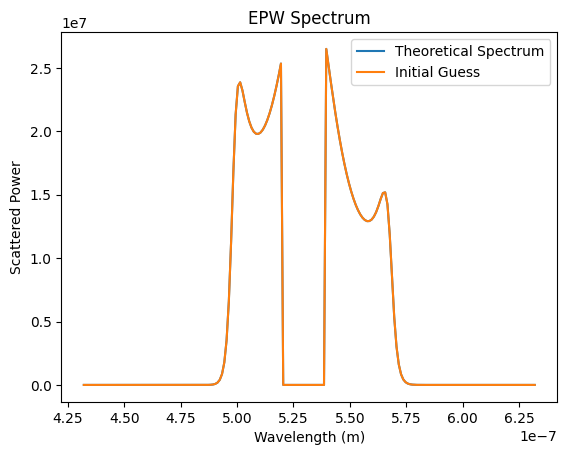

In [10]:

efn = supergaussian_e_TORCH(e_velocity_axis_TORCH, torch.exp(electron_params["ln_e_T"]), electron_params["e_vd"], electron_params["e_p"])
ifn = supergaussian_H_TORCH(i_velocity_axis_TORCH, torch.exp(ion_params["ln_i0_T"]), ion_params["i0_vd"], ion_params["i0_p"])

efn_epw = [efn]
ifn_epw = [ifn]


_, Skw_arbdist_epw = cpu_autodiff_thomson.spectral_density_arbdist(
    epw_wavelengths_TORCH,
    probe_wavelength_TORCH,
    e_velocity_axes_TORCH,
    i_velocity_axes_TORCH,
    efn_epw,
    ifn_epw,
    derivative_matrices,
    torch.exp(electron_params["ln_n"]),
    epw_notches,
    efract_TORCH,
    ifract_TORCH,
    ion_species_TORCH,
    probe_vec_TORCH,
    scatter_vec_TORCH,
    scattered_power_TORCH,
    inner_range=0.1,
    inner_frac=0.8
)




# Plot initial EPW S'
plt.plot(epw_wavelengths_TORCH.numpy(), epw_target, label="Theoretical Spectrum")
plt.plot(epw_wavelengths_TORCH.numpy(), Skw_arbdist_epw.detach().numpy(), label="Initial Guess")
plt.legend(loc="upper right")
plt.xlabel("Wavelength (m)")
plt.ylabel("Scattered Power")
plt.title("EPW Spectrum")
plt.show()

## iiiiii.) Fit EPW

In [11]:
# Construct optimizer for electron parameters
opt_epw = torch.optim.NAdam([
        {"params": (electron_params["ln_n"], electron_params["ln_e_T"],
                    electron_params["e_p"]), "lr":1e-3},
        {"params": (electron_params["e_vd"]), "lr":100}
      ], lr=1e-3, betas=[0.9985, 0.999])






# Calculate initial EPW loss
epw_dist_hist = [Skw_arbdist_epw.detach().clone()]
epw_loss_hist = [float(dist_score(Skw_arbdist_epw, epw_target).detach())]
print(f"Initial EPW loss: {epw_loss_hist}")



# Construct ion VDF now to save redundant calls
ifn = supergaussian_H_TORCH(i_velocity_axis_TORCH, torch.exp(ion_params["ln_i0_T"]), ion_params["i0_vd"], ion_params["i0_p"])
ifn_epw = [ifn]

epw_counter = 0
while True:
#for i in trange(5000):
    opt_epw.zero_grad()

    # Reconstruct electron velocity distribution using updated parameters
    efn = supergaussian_e_TORCH(e_velocity_axis_TORCH, torch.exp(electron_params["ln_e_T"]), electron_params["e_vd"], electron_params["e_p"])
    efn_epw = [efn]

    _, Skw_arbdist_epw = cpu_autodiff_thomson.spectral_density_arbdist(
    epw_wavelengths_TORCH,
    probe_wavelength_TORCH,
    e_velocity_axes_TORCH,
    i_velocity_axes_TORCH,
    efn_epw,
    ifn_epw,
    derivative_matrices,
    torch.exp(electron_params["ln_n"]),
    epw_notches,
    efract_TORCH,
    ifract_TORCH,
    ion_species_TORCH,
    probe_vec_TORCH,
    scatter_vec_TORCH,
    scattered_power_TORCH,
    inner_range=0.1,
    inner_frac=0.8,
    )

    # Caculate NMSE
    epw_loss = dist_score(Skw_arbdist_epw, epw_target)
    opt_epw.step()

    # Append value to loss history
    epw_dist_hist.append(Skw_arbdist_epw.detach().clone())
    epw_loss_hist.append(float(epw_loss.detach()))

    epw_counter += 1

    # Check if criteria of convergence is met
    delta_NMSE = abs(epw_loss_hist[epw_counter] - epw_loss_hist[epw_counter-1])
    if delta_NMSE <= EPW_CUTOFF_CRITERIA and epw_counter >= MIN_NUM_ITERS:
        n_TORCH = torch.exp(electron_params["ln_n"])
        print(f"Exiting loop after {epw_counter} iterations, loss is {delta_NMSE}")
        break





Initial EPW loss: [3.736554238672045e-25]
Exiting loop after 548 iterations, loss is 8.180924674184838e-09


Text(0.5, 1.0, 'EPW Loss History')

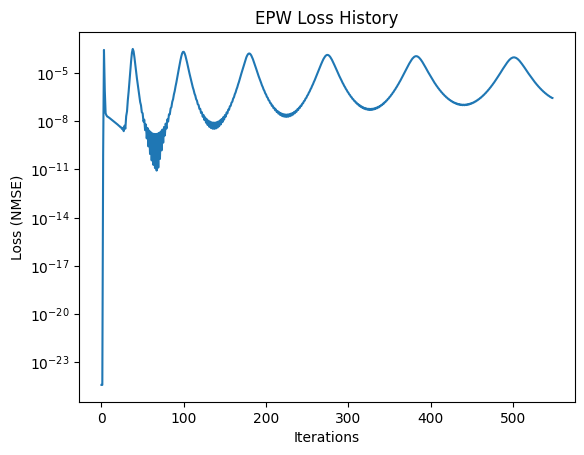

In [12]:
# Plot EPW loss history
plt.semilogy(epw_loss_hist)#[-100:])
plt.xlabel("Iterations")
plt.ylabel("Loss (NMSE)")
plt.title("EPW Loss History")

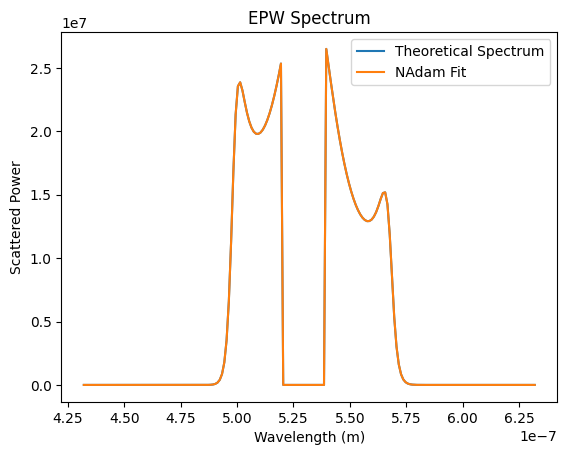

e_T: tensor([299.9914])
e_vd: tensor([99998.0653])
e_p: tensor([4.0000])
n: tensor([3.9999e+24])


In [13]:
# Plot fitted EPW spectrum
plt.plot(epw_wavelengths_TORCH.numpy(), epw_target, label="Theoretical Spectrum")
plt.plot(epw_wavelengths_TORCH.numpy(), Skw_arbdist_epw.detach().numpy(), label="NAdam Fit")
plt.legend(loc = "upper right")
plt.xlabel("Wavelength (m)")
plt.ylabel("Scattered Power")
plt.title("EPW Spectrum")
plt.show()


# Print optimized electron parameters
e_T_optim = torch.exp(electron_params["ln_e_T"]).detach().clone()
e_vd_optim = electron_params["e_vd"].detach().clone()
e_p_optim = electron_params["e_p"].detach().clone()
n_optim = n_TORCH.detach().clone()

print(f"e_T: {e_T_optim}")
print(f"e_vd: {e_vd_optim}")
print(f"e_p: {e_p_optim}")
print(f"n: {n_optim}")

## iiiiiii.) Same Steps as above to Optimize IAW

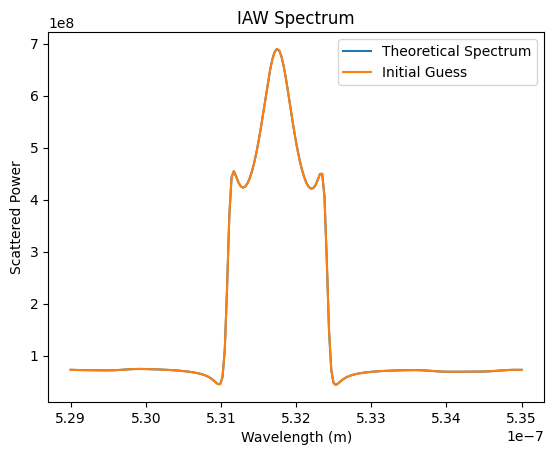

In [14]:
# Enable gradient tracking for ion parameters
if NUM_FREE_PARAMS == NUM_PARAMS:
    for param in ion_params: ion_params[param].requires_grad=True
else:
    for i in range(NUM_FREE_PARAMS-NUM_ELECTRON_PARAMS): ion_params[ion_param_keys[i]].requires_grad=True





efn_optim = supergaussian_e_TORCH(e_velocity_axis_TORCH, e_T_optim, e_vd_optim, e_p_optim)
efn_iaw = [efn_optim]

ifn = supergaussian_H_TORCH(i_velocity_axis_TORCH, torch.exp(ion_params["ln_i0_T"]), ion_params["i0_vd"], ion_params["i0_p"])
ifn_iaw = [ifn]

# Call forward model function to generate initial IAW S'
_, Skw_arbdist_iaw = cpu_autodiff_thomson.spectral_density_arbdist(
    iaw_wavelengths_TORCH,
    probe_wavelength_TORCH,
    e_velocity_axes_TORCH,
    i_velocity_axes_TORCH,
    efn_iaw,
    ifn_iaw,
    derivative_matrices,
    n_optim,
    iaw_notch,
    efract_TORCH,
    ifract_TORCH,
    ion_species_TORCH,
    probe_vec_TORCH,
    scatter_vec_TORCH,
    scattered_power_TORCH,
    inner_range=0.1,
    inner_frac=0.8,
)





# Plot initial IAW S'
plt.plot(iaw_wavelengths_TORCH.numpy(), iaw_target, label="Theoretical Spectrum")
plt.plot(iaw_wavelengths_TORCH.numpy(), Skw_arbdist_iaw.detach().numpy(), label="Initial Guess")
plt.legend(loc = "upper right")
plt.xlabel("Wavelength (m)")
plt.ylabel("Scattered Power")
plt.title("IAW Spectrum")
plt.show()



In [15]:

# Construct optimizer for ion parameters
opt_iaw = torch.optim.NAdam([
        {"params": (ion_params["i0_p"], ion_params["ln_i0_T"]), "lr":1e-3},
        {"params": (ion_params["i0_vd"]), "lr":100}
      ], lr=1e-3, betas=[0.9985, 0.999])



# Calculate initial IAW loss
iaw_dist_hist = [Skw_arbdist_iaw.detach().clone()]
iaw_loss_hist = [float(dist_score(Skw_arbdist_iaw, iaw_target).detach())]
print(f"Initial IAW Loss: {iaw_loss_hist}")




# Construct fitted electron VDF now to save redundant calls
efn_optim = supergaussian_e_TORCH(e_velocity_axis_TORCH, e_T_optim, e_vd_optim, e_p_optim)
efn_iaw = [efn_optim]

iaw_counter = 0
while True:
#for i in trange(3000):
    opt_iaw.zero_grad()

    # Reconstruct ion velocity distribution using updated parameters
    ifn = supergaussian_H_TORCH(i_velocity_axis_TORCH, torch.exp(ion_params["ln_i0_T"]), ion_params["i0_vd"], ion_params["i0_p"])
    ifn_iaw = [ifn]

    _, Skw_arbdist_iaw = cpu_autodiff_thomson.spectral_density_arbdist(
    iaw_wavelengths_TORCH,
    probe_wavelength_TORCH,
    e_velocity_axes_TORCH,
    i_velocity_axes_TORCH,
    efn_iaw,
    ifn_iaw,
    derivative_matrices,
    n_optim,
    iaw_notch,
    efract_TORCH,
    ifract_TORCH,
    ion_species_TORCH,
    probe_vec_TORCH,
    scatter_vec_TORCH,
    scattered_power_TORCH,
    inner_range=0.1,
    inner_frac=0.8,
    )

    # Caculate NMSE
    iaw_loss = dist_score(Skw_arbdist_iaw, iaw_target)
    opt_iaw.step()

    # Append value to loss history
    iaw_dist_hist.append(Skw_arbdist_iaw.detach().clone())
    iaw_loss_hist.append(float(iaw_loss.detach()))

    iaw_counter += 1

    # Check if criteria of convergence is met
    delta_NMSE = abs(iaw_loss_hist[iaw_counter] - iaw_loss_hist[iaw_counter-1])
    if delta_NMSE <= IAW_CUTOFF_CRITERIA and iaw_counter >= MIN_NUM_ITERS:
        print(f"Exiting loop after {iaw_counter} iterations, loss is {delta_NMSE}")
        break

Initial IAW Loss: [2.1066404059284664e-08]
Exiting loop after 523 iterations, loss is 7.304474654425624e-08


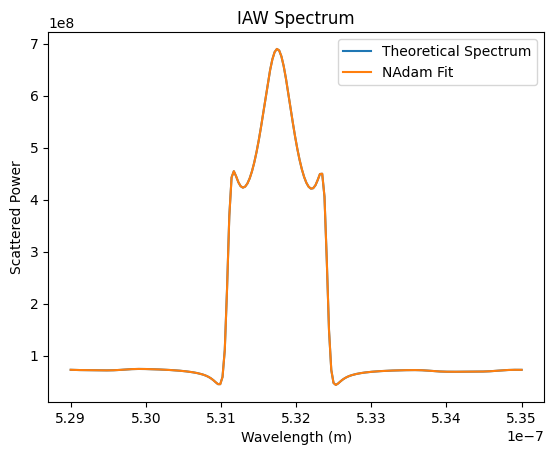

i0_T: tensor([200.0641])
i0_vd: tensor([100030.3673])
i0_p: tensor([3.9997])


In [16]:
# Plot fitted IAW spectrum
plt.plot(iaw_wavelengths_TORCH.numpy(), iaw_target, label="Theoretical Spectrum")
plt.plot(iaw_wavelengths_TORCH.numpy(), Skw_arbdist_iaw.detach().numpy(), label="NAdam Fit")
plt.legend(loc="upper right")
plt.xlabel("Wavelength (m)")
plt.ylabel("Scattered Power")
plt.title("IAW Spectrum")
plt.show()



# Print optimized ion parameters
i0_T_optim = torch.exp(ion_params["ln_i0_T"]).detach().clone()
i0_vd_optim = ion_params["i0_vd"].detach().clone()
i0_p_optim = ion_params["i0_p"].detach().clone()

print(f"i0_T: {i0_T_optim}")
print(f"i0_vd: {i0_vd_optim}")
print(f"i0_p: {i0_p_optim}")